## Loan Application Status Prediction and Analysis

### Problem Statement:

This dataset includes details of applicants who have applied for loan. The dataset includes details like credit history, loan amount, their income, dependents etc.

### Dataset Description:

Loan_ID : Unique Loan ID

Gender : Male/ Female

Married : Applicant married (Y/N)

Dependents : Number of dependents

Education : Applicant Education (Graduate/ Under Graduate)

Self_Employed : Self employed (Y/N)

ApplicantIncome : Applicant income

CoapplicantIncome : Coapplicant income

LoanAmount : Loan amount in thousands of dollars

Loan_Amount_Term : Term of loan in months

Credit_History : credit history meets guidelines yes or no

Property_Area : Urban/ Semi Urban/ Rural

Loan_Status : Loan approved (Y/N) this is the target variable

### Goal:


You have to build a model that can predict whether the loan of the applicant will be approved or not on the basis of the details provided in the dataset.

Dependent Variable (Target Variable): Loan_Status


### Importing Libraries

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, OneHotEncoder,\
    StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### Data Loading and initial analysis

In [218]:
df=pd.read_csv('loan_prediction.csv')

In [219]:
# Display the first 5 rows of the dataset
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [220]:
# Display general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [221]:
# checking for duplicate values
print(df.duplicated().sum())

0


In [222]:
# checking for missing values
df.isnull().sum().sort_values(ascending=False)

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
Loan_ID               0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64

In [223]:
# Displaying all the values counts in category columns
category=['Credit_History','Gender','Married','Dependents',\
        'Education','Self_Employed','Property_Area',\
        'Loan_Status']
for i in category:
    print(df[i].value_counts())
    print('-----------------------------')

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64
-----------------------------
Gender
Male      489
Female    112
Name: count, dtype: int64
-----------------------------
Married
Yes    398
No     213
Name: count, dtype: int64
-----------------------------
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
-----------------------------
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
-----------------------------
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
-----------------------------
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
-----------------------------
Loan_Status
Y    422
N    192
Name: count, dtype: int64
-----------------------------


- There are no duplicate records in the data but there are missing values.

- Most of the features are of categorical type('Credit_History' is binary categorical feature even though its type is float).

- 'Loan_ID' column is not needed for model so i can be removed. 

- The four features with 'float64' data type have whole numbers so they can be changed to 'int64' data type.

### Data Cleaning

In [224]:
# remove Loan_ID column as it is not useful for prediction
df.drop('Loan_ID', axis=1, inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [225]:
# Display all missing value count and data types of all columns
pd.concat([df.isnull().sum(), df.dtypes], axis=1)\
    .rename(columns={0: 'Missing Values', 1: 'Data Type'})

,Missing Values,Data Type
Gender,13,object
Married,3,object
Dependents,15,object
Education,0,object
Self_Employed,32,object
ApplicantIncome,0,int64
CoapplicantIncome,0,float64
LoanAmount,22,float64
Loan_Amount_Term,14,float64
Credit_History,50,float64


In [226]:
# Filling missing values in categorical columns with mode
for col in category:
    df[col].fillna(df[col].mode()[0], inplace=True)
pd.concat([df.isnull().sum(), df.dtypes], axis=1)\
    .rename(columns={0: 'Missing Values', 1: 'Data Type'})

,Missing Values,Data Type
Gender,0,object
Married,0,object
Dependents,0,object
Education,0,object
Self_Employed,0,object
ApplicantIncome,0,int64
CoapplicantIncome,0,float64
LoanAmount,22,float64
Loan_Amount_Term,14,float64
Credit_History,0,float64


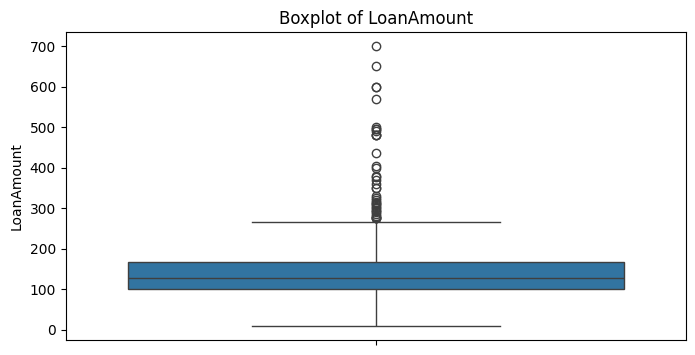

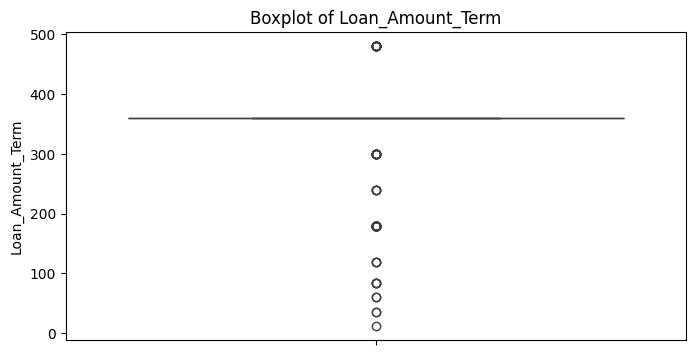

In [227]:
# checking for outliers in numerical columns using boxplot
numerical_miss=['LoanAmount', 'Loan_Amount_Term']
for col in numerical_miss:
    plt.figure(figsize=(8, 4))
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [228]:
# Filling missing values in numerical columns with median
for col in numerical_miss:
    df[col].fillna(df[col].median(), inplace=True)

pd.concat([df.isnull().sum(), df.dtypes], axis=1)\
    .rename(columns={0: 'Missing Values', 1: 'Data Type'})

,Missing Values,Data Type
Gender,0,object
Married,0,object
Dependents,0,object
Education,0,object
Self_Employed,0,object
ApplicantIncome,0,int64
CoapplicantIncome,0,float64
LoanAmount,0,float64
Loan_Amount_Term,0,float64
Credit_History,0,float64


- Missing values of all the features with missing values except 'LoanAmount' and 'Loan_Amount_Term' were filled with mode since they were categorical features.

- 'LoanAmount' and 'Loan_Amount_Term' feature had outliers so they were filled with median.

### EDA

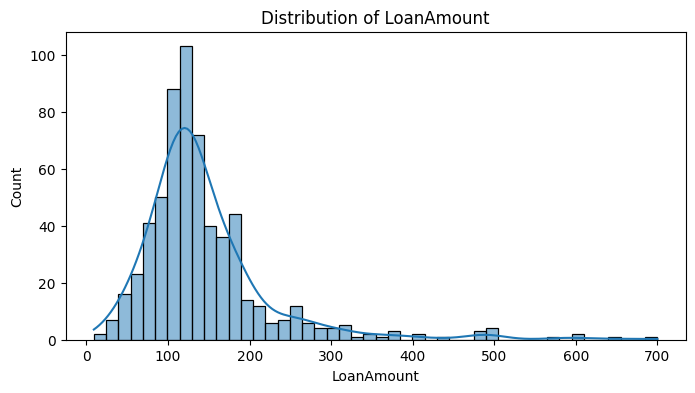

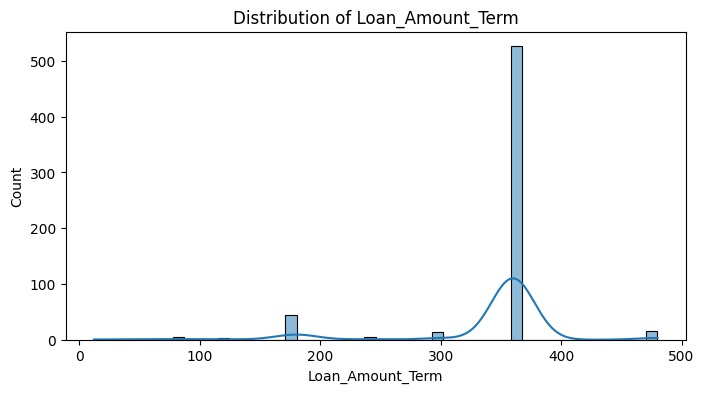

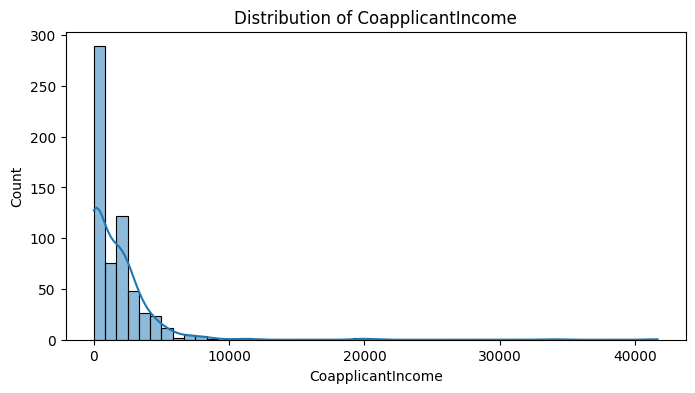

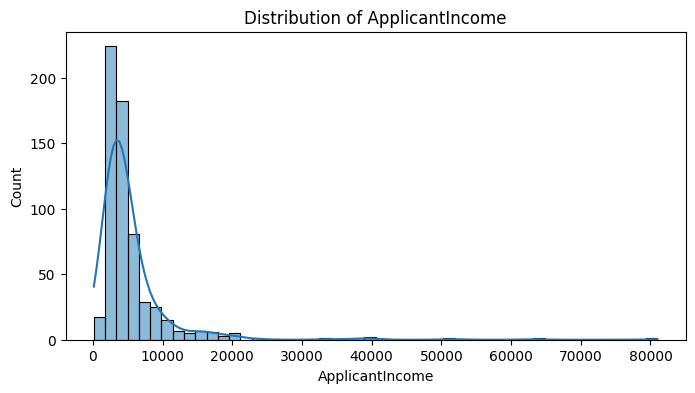

In [229]:
# find the distribution of numerical columns using histogram

numerical=['LoanAmount', 'Loan_Amount_Term',\
            'CoapplicantIncome', 'ApplicantIncome']

for col in numerical:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [230]:
# Find the skewness of numerical columns
for col in numerical:
    skewness = df[col].skew()
    print(f'Skewness of {col}: {skewness}')

Skewness of LoanAmount: 2.743052748820892
Skewness of Loan_Amount_Term: -2.4021122563890396
Skewness of CoapplicantIncome: 7.491531216657306
Skewness of ApplicantIncome: 6.539513113994625


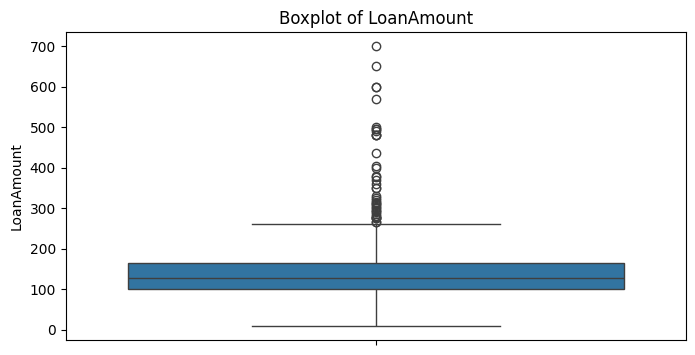

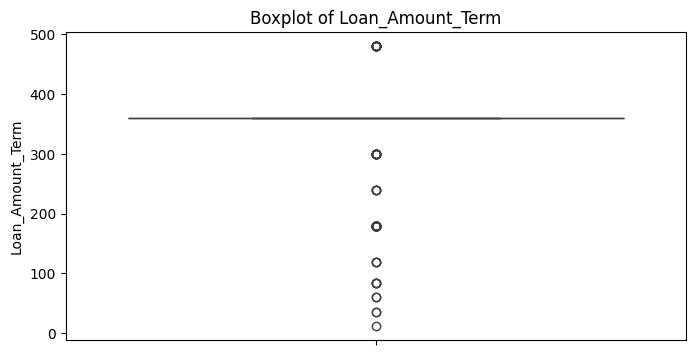

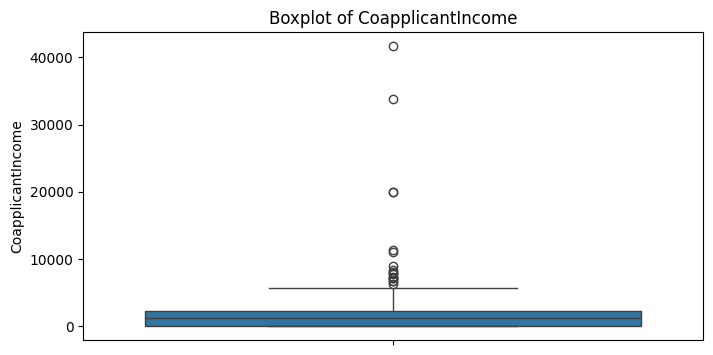

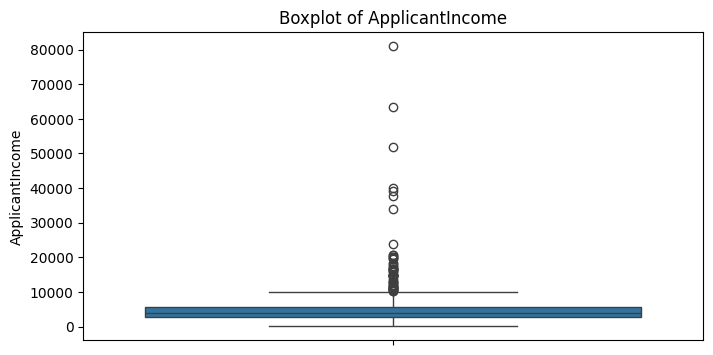

In [231]:
# Find the outliers in numerical columns using boxplot
for col in numerical:
    plt.figure(figsize=(8, 4))
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Skewness of 'ApplicantIncome' and 'CoapplicantIncome' is too much due to outliers so first apply Cap using percentile then apply PowerTransformation to all four  numerical features.

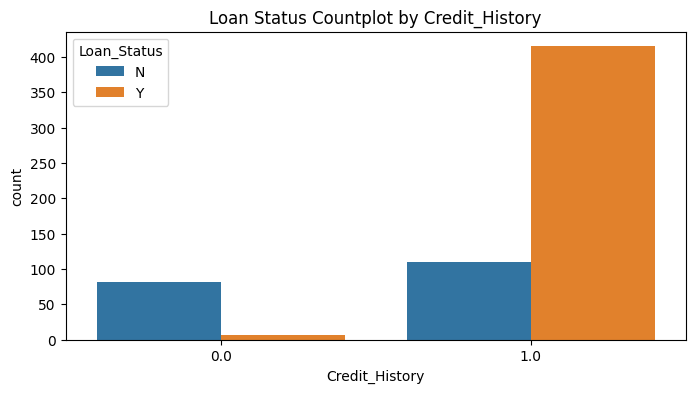

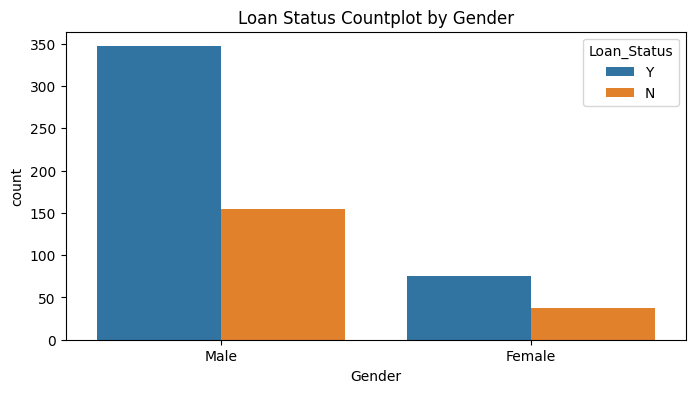

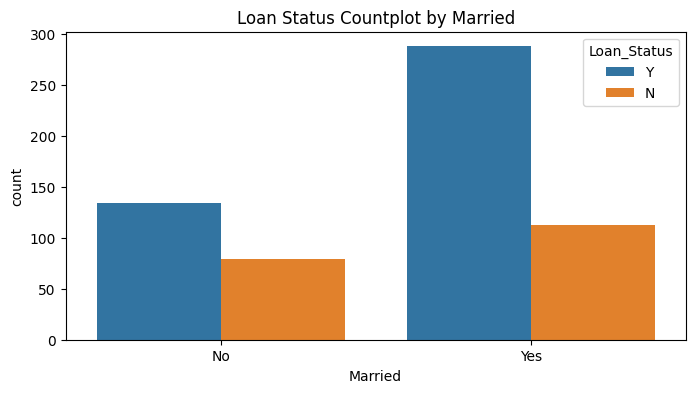

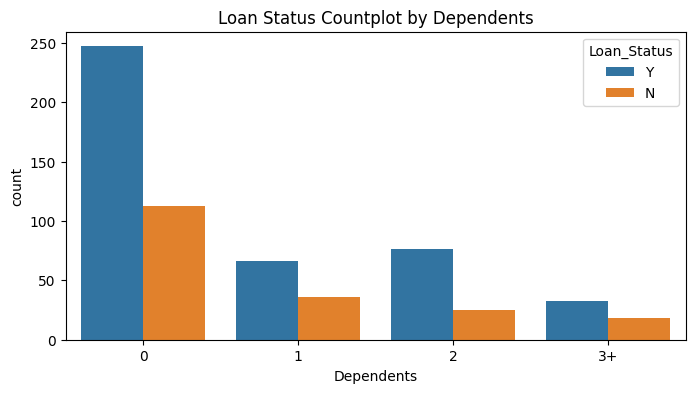

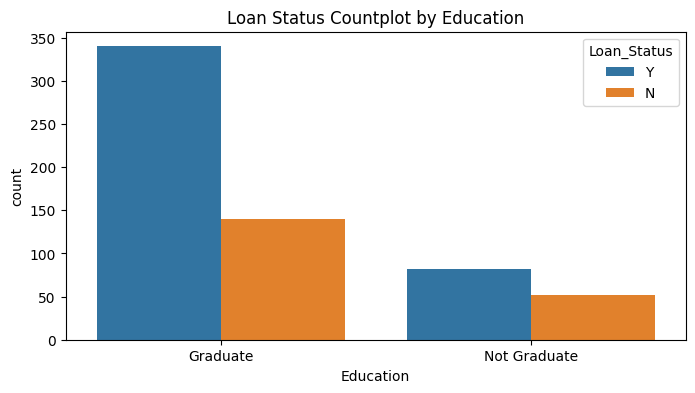

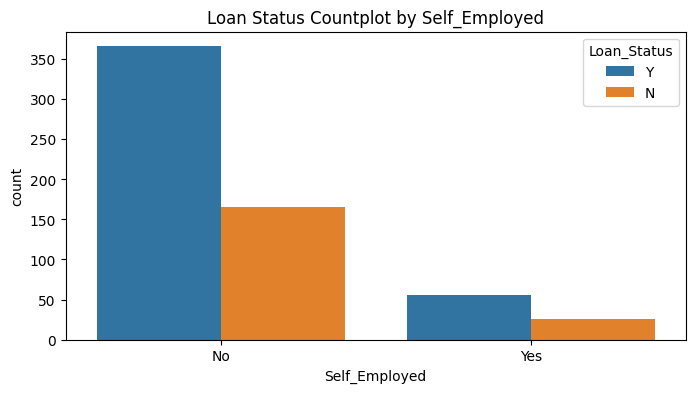

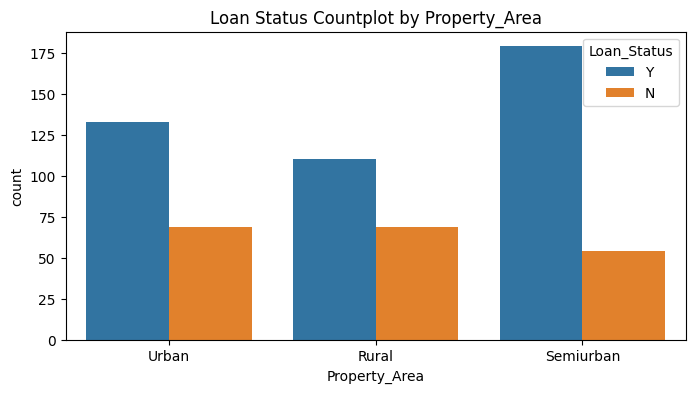

In [232]:
# Loan status countplot across different categorical features
for col in category:
    if col != 'Loan_Status':
        plt.figure(figsize=(8, 4))
        sns.countplot(x=col, hue='Loan_Status', data=df)
        plt.title(f'Loan Status Countplot by {col}')
        plt.show()

### Preprocessing

In [233]:
# Changing binary categorical columns into numerical format
df['Gender']=df['Gender'].map({'Male': 1, 'Female': 0})
df['Married']=df['Married'].map({'Yes': 1, 'No': 0})
df['Education']=df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed']=df['Self_Employed'].map({'Yes': 1, 'No': 0})

In [234]:
# change the 3+ values in Dependents column to 3
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# display the data types of all columns
df.dtypes

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [235]:
# OneHot encode the Property_Area column
encoder = OneHotEncoder(dtype=int)
encoded_cols = encoder.fit_transform(df[['Property_Area']])
encoded_df = pd.DataFrame(encoded_cols.toarray(), columns=encoder.get_feature_names_out(['Property_Area']))
df = pd.concat([df, encoded_df], axis=1)
df.drop('Property_Area', axis=1, inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Y,0,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,N,1,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Y,0,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Y,0,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Y,0,0,1


In [236]:
# Apply 98.5 percentile capping for ApplicantIncome and CoapplicantIncome
for col in ['ApplicantIncome', 'CoapplicantIncome']:
    upper_limit = df[col].quantile(0.985)
    df[col] = df[col].clip(upper=upper_limit)

# Check skewness after capping
for col in numerical:
    skewness = df[col].skew()
    print(f'Skewness of {col}: {skewness}')

Skewness of LoanAmount: 2.743052748820892
Skewness of Loan_Amount_Term: -2.4021122563890396
Skewness of CoapplicantIncome: 1.442862158101783
Skewness of ApplicantIncome: 2.333724746505801


In [237]:
# Apply Power Transformation to reduce skewness
pt = PowerTransformer(method='yeo-johnson')
for col in numerical:
    df[col] = pt.fit_transform(df[[col]])

print("After Power Transformation,")
for col in numerical:
    skewness = df[col].skew()
    print(f'Skewness of {col}: {skewness}')

After Power Transformation,
Skewness of LoanAmount: 0.02083124629879896
Skewness of Loan_Amount_Term: 0.39257143964967994
Skewness of CoapplicantIncome: -0.15945035092748813
Skewness of ApplicantIncome: -0.009036772093179022


In [238]:
# Apply Standardization to numerical columns
scaler = StandardScaler()
for col in numerical:
    df[col] = scaler.fit_transform(df[[col]])
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,0.562445,-1.104731,-0.025462,0.17554,1.0,Y,0,0,1
1,1,1,1,1,0,0.165750,0.755253,-0.025462,0.17554,1.0,N,1,0,0
2,1,1,0,1,1,-0.527089,-1.104731,-1.339826,0.17554,1.0,Y,0,0,1
3,1,1,0,0,0,-0.772909,0.899406,-0.155876,0.17554,1.0,Y,0,0,1
4,1,0,0,1,0,0.603810,-1.104731,0.170931,0.17554,1.0,Y,0,0,1


In [239]:
# Change the data type of certain float columns to int

df['Credit_History'] = df['Credit_History'].astype(int)

# Final check of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    float64
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    int64  
 10  Loan_Status              614 non-null    object 
 11  Property_Area_Rural      614 non-null    int64  
 12  Property_Area_Semiurban  614 non-null    int64  
 13  Property_Area_Urban      614 non-null    int64  
dtypes: float64(4), int64(9), o

In [240]:
# Check the dataset after preprocessing
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,0.562445,-1.104731,-0.025462,0.17554,1,Y,0,0,1
1,1,1,1,1,0,0.165750,0.755253,-0.025462,0.17554,1,N,1,0,0
2,1,1,0,1,1,-0.527089,-1.104731,-1.339826,0.17554,1,Y,0,0,1
3,1,1,0,0,0,-0.772909,0.899406,-0.155876,0.17554,1,Y,0,0,1
4,1,0,0,1,0,0.603810,-1.104731,0.170931,0.17554,1,Y,0,0,1


### Model Building

In [241]:
# Train-test split
x = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

x_train, x_test, y_train, y_test = \
    train_test_split(x, y, test_size=0.2, random_state=42)

#### Logistic regression

In [242]:
# Creating logistic regression model
lr=LogisticRegression()
lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [243]:
# making predictions
y_pred_1=lr.predict(x_test)

In [244]:
# Testing the model
print("Confusion Matrix:\n", \
        confusion_matrix(y_test, y_pred_1))
print("Accuracy Score:\n", \
        f"{accuracy_score(y_test, y_pred_1)*100:.2f}%")

Confusion Matrix:
 [[18 25]
 [ 1 79]]
Accuracy Score:
 78.86%


#### Decision Tree Classifier

In [245]:
# Decision Tree Classifier
dtc=DecisionTreeClassifier(random_state=42)
dtc.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [246]:
# Make predictions
y_pred_2=dtc.predict(x_test)

In [247]:
# Test the model
print("Confusion Matrix:\n", \
        confusion_matrix(y_test, y_pred_2))
print("Accuracy Score:\n", \
        f"{accuracy_score(y_test, y_pred_2)*100:.2f}%")

Confusion Matrix:
 [[25 18]
 [12 68]]
Accuracy Score:
 75.61%


#### Random Forest Classifier

In [248]:
# Random Forest Classifier
rtc=RandomForestClassifier(random_state=42)
rtc.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [249]:
# Make predictions
y_pred_3=rtc.predict(x_test)

In [250]:
# test the model
print("Confusion Matrix:\n", \
        confusion_matrix(y_test, y_pred_3))
print("Accuracy Score:\n", \
        f"{accuracy_score(y_test, y_pred_3)*100:.2f}%")

Confusion Matrix:
 [[19 24]
 [ 4 76]]
Accuracy Score:
 77.24%


### Conclusion

Logistic Regression gives the best result.